# LAB | Build Simple Neural Network


Author: Louise Plessis


## Part 1: Cat & Dogs

### Step 1: Setting Up the Environment

In [22]:
#pip install tensorflow numpy matplotlib

In [2]:

#Dog vs Cat Image Classifier
#Description: Build a simple neural network to classify dog and cat images
 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
 
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
 
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
Keras version: 3.15.0
GPU available: []


### Step 2: Loading and Preparing the Data

In [12]:
"""
I got an error with the code from the class and the data loading was 2hr + so I run git clone --depth 1 https://github.com/YoongiKim/CIFAR-10-images.git cifar_data
on my termnial and adapted the code below to load the data from the local folder.

"""


import os
import numpy as np
from PIL import Image

DATA_DIR = "cifar_data"
cat_class = 3
dog_class = 5

def load_images_for_class(split, class_name):
    folder = os.path.join(DATA_DIR, split, class_name)
    files = sorted(os.listdir(folder))
    imgs = np.zeros((len(files), 32, 32, 3), dtype=np.uint8)
    for i, fname in enumerate(files):
        with Image.open(os.path.join(folder, fname)) as im:
            imgs[i] = np.array(im.convert('RGB'))
    return imgs

print("Loading CIFAR-10 dataset (cat/dog only)...")
train_cats = load_images_for_class('train', 'cat')
train_dogs = load_images_for_class('train', 'dog')
test_cats = load_images_for_class('test', 'cat')
test_dogs = load_images_for_class('test', 'dog')

x_train = np.concatenate([train_cats, train_dogs], axis=0)
y_train = np.concatenate([np.zeros(len(train_cats)), np.ones(len(train_dogs))]).astype(int)

x_test = np.concatenate([test_cats, test_dogs], axis=0)
y_test = np.concatenate([np.zeros(len(test_cats)), np.ones(len(test_dogs))]).astype(int)

# Shuffle so cats/dogs aren't ordered in blocks
rng = np.random.default_rng(42)
train_perm = rng.permutation(len(x_train))
x_train, y_train = x_train[train_perm], y_train[train_perm]
test_perm = rng.permutation(len(x_test))
x_test, y_test = x_test[test_perm], y_test[test_perm]

print(f"Training: {x_train.shape[0]} images, Test: {x_test.shape[0]} images")

Loading CIFAR-10 dataset (cat/dog only)...
Training: 10000 images, Test: 2000 images


In [13]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten images for simple neural network (32x32x3 = 3072)
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print(f"Flattened shape: {x_train_flat.shape}")

Flattened shape: (10000, 3072)


### Step 3: Building Your First Neural Network

In [14]:
# Build the neural network
print("\n" + "="*50)
print("BUILDING NEURAL NETWORK")
print("="*50)
 
# Simple feedforward neural network
model = keras.Sequential([
    # Input layer: 3072 features (32*32*3)
    layers.Dense(128, activation='relu', input_shape=(3072,), name='hidden_layer_1'),
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    # Output layer: 1 neuron for binary classification (dog or cat)
    layers.Dense(1, activation='sigmoid', name='output_layer')
])
 
# Compile the model
model.compile(
    optimizer='adam',           # Optimization algorithm
    loss='binary_crossentropy', # Loss function for binary classification
    metrics=['accuracy']        # Metric to track during training
)
 
# Display model architecture
print("\nModel Architecture:")
model.summary()
 
# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")


BUILDING NEURAL NETWORK

Model Architecture:


/opt/miniconda3/envs/bootcamp-env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,665 (1.53 MB)

 Trainable params: 401,665 (1.53 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 401,665


### Step 4: Training the Model

In [21]:
# Train the model

print("\n" + "="*50)
print("TRAINING THE MODEL")
print("="*50)
 
# Training parameters
EPOCHS = 20
BATCH_SIZE = 32
 
print(f"Training for {EPOCHS} epochs with batch size {BATCH_SIZE}...")
 
# Train the model
history = model.fit(
    x_train_flat, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test_flat, y_test),
    verbose=1  # Show progress bar
)
 
print("\n✓ Training complete!")


TRAINING THE MODEL
Training for 20 epochs with batch size 32...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6357 - loss: 0.6291 - val_accuracy: 0.6040 - val_loss: 0.6701
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6400 - loss: 0.6265 - val_accuracy: 0.6065 - val_loss: 0.6636
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6423 - loss: 0.6260 - val_accuracy: 0.6060 - val_loss: 0.6656
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6414 - loss: 0.6232 - val_accuracy: 0.5960 - val_loss: 0.6620
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6421 - loss: 0.6209 - val_accuracy: 0.6070 - val_loss: 0.6668
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6418 - loss: 0.6202 - val_accuracy: 0.6070 - val_loss: 0.6659
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6426 - loss: 0.6230 - val_accuracy: 0.6110 - val_loss: 0.6671
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━

### Step 5: Evaluating the Model


EVALUATING THE MODEL
Test Loss: 0.6646
Test Accuracy: 0.6075 (60.75%)
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step

Manual accuracy check: 1215/2000 (60.75%)

Saved training history to 'training_history.png'


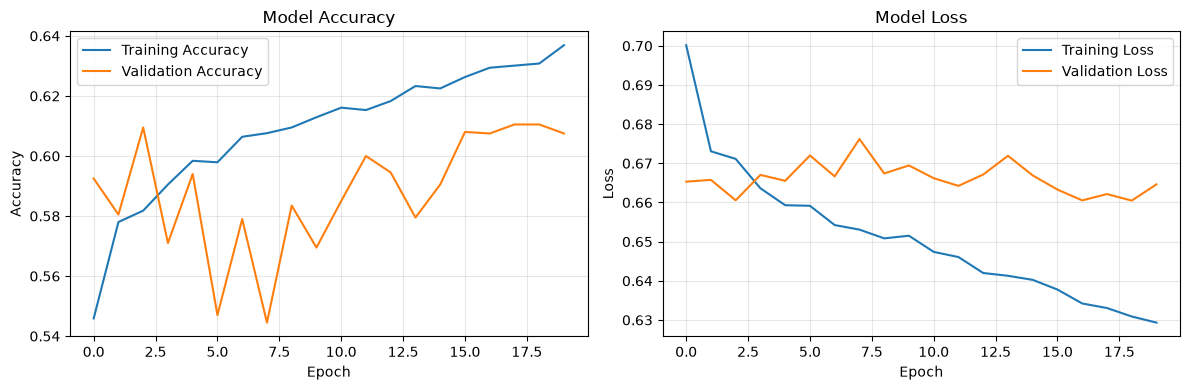


SAMPLE PREDICTIONS
Saved sample predictions to 'sample_predictions.png'


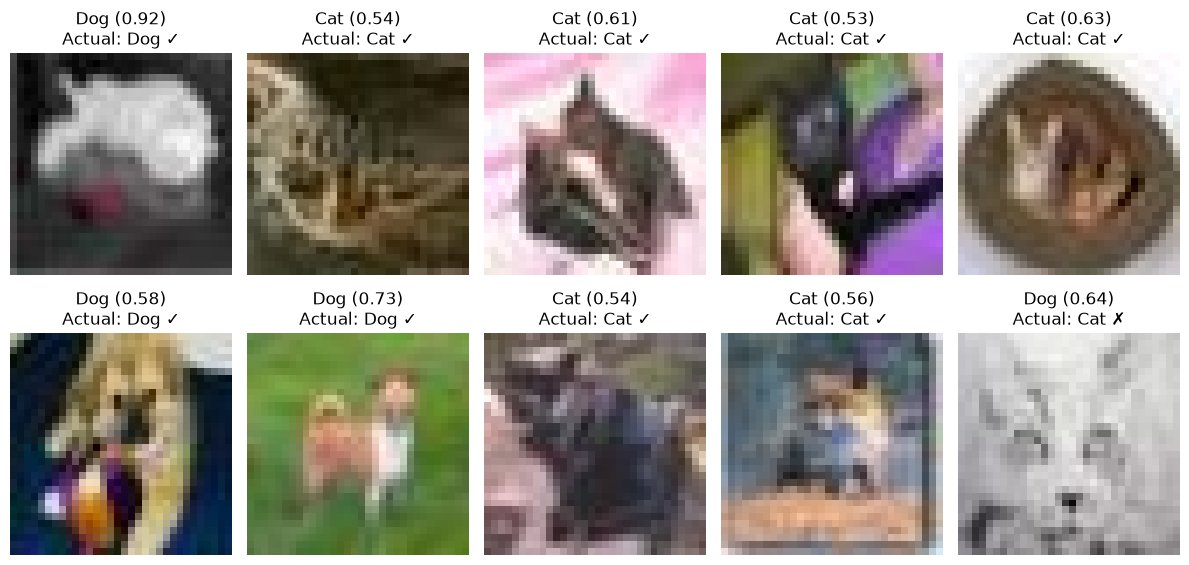

In [16]:
# Evaluate the model
print("\n" + "="*50)
print("EVALUATING THE MODEL")
print("="*50)
 
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
 
# Make predictions on test set
predictions = model.predict(x_test_flat)
predicted_classes = (predictions > 0.5).astype(int).flatten()
 
# Calculate accuracy manually
correct = (predicted_classes == y_test.flatten()).sum()
total = len(y_test)
print(f"\nManual accuracy check: {correct}/{total} ({correct/total*100:.2f}%)")
 
# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
print("\nSaved training history to 'training_history.png'")
plt.show()
 
# Test on some sample images
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)
 
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row = i // 5
    col = i % 5
    
    # Get prediction
    img = x_test[i].reshape(1, -1)
    pred = model.predict(img, verbose=0)[0][0]
    pred_class = 'Dog' if pred > 0.5 else 'Cat'
    confidence = pred if pred > 0.5 else 1 - pred
    
    # Actual label
    actual = 'Dog' if y_test[i] == 1 else 'Cat'
    correct = '✓' if (pred > 0.5) == (y_test[i] == 1) else '✗'
    
    axes[row, col].imshow(x_test[i])
    axes[row, col].set_title(f'{pred_class} ({confidence:.2f})\nActual: {actual} {correct}')
    axes[row, col].axis('off')
 
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
print("Saved sample predictions to 'sample_predictions.png'")
plt.show()

### Step 6: Exporting Model Weights

In [19]:
# Export model weights
print("\n" + "="*50)
print("EXPORTING MODEL WEIGHTS")
print("="*50)
 
# Create directory for saved models
import os
os.makedirs('saved_models', exist_ok=True)
 
# Method 1: Save entire model — use native .keras format instead of .h5 (legacy warning)
model_path = 'saved_models/dog_cat_classifier_full.keras'
model.save(model_path)
print(f"✓ Saved full model to: {model_path}")
print(f"  File size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

# Method 2: Save only weights — filename must end in .weights.h5
weights_path = 'saved_models/dog_cat_classifier.weights.h5'
model.save_weights(weights_path)
print(f"✓ Saved weights only to: {weights_path}")
print(f"  File size: {os.path.getsize(weights_path) / 1024 / 1024:.2f} MB")
 
# Method 3: Save in SavedModel format (TensorFlow's recommended format)
# Note: keras 3 no longer supports model.save() for plain SavedModel dirs.
# Use model.export() instead if you specifically need this format:
# model.export(savedmodel_path)

# Replace Method 3 with the following code to save in SavedModel format

savedmodel_path = 'saved_models/dog_cat_classifier_savedmodel'
model.export(savedmodel_path)
print(f"✓ Saved in SavedModel format to: {savedmodel_path}/")
 
# Verify we can load the model
print("\nVerifying saved model...")
loaded_model = keras.models.load_model(model_path)
test_loss_loaded, test_acc_loaded = loaded_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Loaded model test accuracy: {test_acc_loaded:.4f}")
print(f"Original model test accuracy: {test_accuracy:.4f}")
print(f"Match: {'✓' if abs(test_acc_loaded - test_accuracy) < 0.001 else '✗'}")
 
print("\n✓ Model weights exported successfully!")


EXPORTING MODEL WEIGHTS
✓ Saved full model to: saved_models/dog_cat_classifier_full.keras
  File size: 4.62 MB
✓ Saved weights only to: saved_models/dog_cat_classifier.weights.h5
  File size: 4.62 MB
INFO:tensorflow:Assets written to: saved_models/dog_cat_classifier_savedmodel/assets


INFO:tensorflow:Assets written to: saved_models/dog_cat_classifier_savedmodel/assets


Saved artifact at 'saved_models/dog_cat_classifier_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3072), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5890276240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5890273168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5890276816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5890277200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5890276432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5890277008: TensorSpec(shape=(), dtype=tf.resource, name=None)
✓ Saved in SavedModel format to: saved_models/dog_cat_classifier_savedmodel/

Verifying saved model...
Loaded model test accuracy: 0.6075
Original model test accuracy: 0.6075
Match: ✓

✓ Model weights exported successfully!


/opt/miniconda3/envs/bootcamp-env/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Step 7: Experimentation

In [20]:
import time
 
experiments = [
    {
        "name": "Baseline (2 layers, 128-64, relu, adam, lr=0.001)",
        "layers_config": [128, 64],
        "activation": "relu",
        "optimizer": keras.optimizers.Adam(learning_rate=0.001),
        "epochs": 20,
        "batch_size": 32,
    },
    {
        "name": "Deeper (4 layers, 256-128-64-32, relu, adam)",
        "layers_config": [256, 128, 64, 32],
        "activation": "relu",
        "optimizer": keras.optimizers.Adam(learning_rate=0.001),
        "epochs": 20,
        "batch_size": 32,
    },
    {
        "name": "Wider (2 layers, 512-256, relu, adam)",
        "layers_config": [512, 256],
        "activation": "relu",
        "optimizer": keras.optimizers.Adam(learning_rate=0.001),
        "epochs": 20,
        "batch_size": 32,
    },
    {
        "name": "Higher learning rate (2 layers, 128-64, relu, adam, lr=0.01)",
        "layers_config": [128, 64],
        "activation": "relu",
        "optimizer": keras.optimizers.Adam(learning_rate=0.01),
        "epochs": 20,
        "batch_size": 32,
    },
    {
        "name": "tanh activation (2 layers, 128-64, tanh, adam)",
        "layers_config": [128, 64],
        "activation": "tanh",
        "optimizer": keras.optimizers.Adam(learning_rate=0.001),
        "epochs": 20,
        "batch_size": 32,
    },
]
 
results = []
 
for exp in experiments:
    print("\n" + "=" * 60)
    print(f"Running: {exp['name']}")
    print("=" * 60)
 
    # Build model dynamically from layers_config
    exp_layers = [layers.Input(shape=(3072,))]
    for units in exp["layers_config"]:
        exp_layers.append(layers.Dense(units, activation=exp["activation"]))
    exp_layers.append(layers.Dense(1, activation="sigmoid"))
 
    exp_model = keras.Sequential(exp_layers)
    exp_model.compile(
        optimizer=exp["optimizer"],
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
 
    start = time.time()
    hist = exp_model.fit(
        x_train_flat, y_train,
        batch_size=exp["batch_size"],
        epochs=exp["epochs"],
        validation_data=(x_test_flat, y_test),
        verbose=0,  # keep output quiet across 5 runs
    )
    elapsed = time.time() - start
 
    test_loss, test_acc = exp_model.evaluate(x_test_flat, y_test, verbose=0)
    total_params = exp_model.count_params()
 
    results.append({
        "name": exp["name"],
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "params": total_params,
        "train_time_sec": elapsed,
        "final_train_acc": hist.history["accuracy"][-1],
    })
 
    print(f"Test accuracy: {test_acc:.4f} | Params: {total_params:,} | Time: {elapsed:.1f}s")
 
# ============================================================
# Summary table
# ============================================================
print("\n" + "=" * 90)
print("SUMMARY OF ALL EXPERIMENTS")
print("=" * 90)
print(f"{'Experiment':<55} {'Test Acc':<10} {'Params':<12} {'Time (s)':<10}")
print("-" * 90)
for r in sorted(results, key=lambda x: -x["test_accuracy"]):
    print(f"{r['name']:<55} {r['test_accuracy']:<10.4f} {r['params']:<12,} {r['train_time_sec']:<10.1f}")


Running: Baseline (2 layers, 128-64, relu, adam, lr=0.001)
Test accuracy: 0.6170 | Params: 401,665 | Time: 10.6s

Running: Deeper (4 layers, 256-128-64-32, relu, adam)
Test accuracy: 0.5985 | Params: 829,953 | Time: 18.3s

Running: Wider (2 layers, 512-256, relu, adam)
Test accuracy: 0.6100 | Params: 1,704,961 | Time: 37.5s

Running: Higher learning rate (2 layers, 128-64, relu, adam, lr=0.01)
Test accuracy: 0.6190 | Params: 401,665 | Time: 10.7s

Running: tanh activation (2 layers, 128-64, tanh, adam)
Test accuracy: 0.5910 | Params: 401,665 | Time: 11.3s

SUMMARY OF ALL EXPERIMENTS
Experiment                                              Test Acc   Params       Time (s)  
------------------------------------------------------------------------------------------
Higher learning rate (2 layers, 128-64, relu, adam, lr=0.01) 0.6190     401,665      10.7      
Baseline (2 layers, 128-64, relu, adam, lr=0.001)       0.6170     401,665      10.6      
Wider (2 layers, 512-256, relu, adam)   